<a href="https://colab.research.google.com/github/xKevin441/SIS420-IA-Kevin-Tarqui/blob/main/Laboratorio%2002%20Regresi%C3%B3n%20log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 02


# Descripción del dataset
- **Nombre:** Tarqui Mita Kevin Rolando
- **Dataset:** Dota2 Games Results
- **Caracteríscticas (n):** 115
- **Ejemplos (m):** 102944

**Dota 2** es un popular videojuego de estrategia en tiempo real (MOBA) donde dos equipos de 5 jugadores se enfrentan. Antes de cada partida, cada jugador selecciona un *héroe* único con habilidades distintas. En total hay 113 héroes disponibles, pero en cada partida solo se eligen 10 (5 por equipo).

El conjunto de datos contiene **102,944 partidas** registradas el 13 de agosto de 2016


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cargar los datos

In [ ]:
# El CSV no tiene encabezado; se asignan nombres manualmente.
col_names = ['win', 'cluster_id', 'game_mode', 'game_type'] + \
            [f'hero_{i}' for i in range(1, 114)]

# Se utilizan los datasets de entrenamiento y prueba
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/dota2Train.csv', header=None, names=col_names)
df_test  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/dota2Test.csv',  header=None, names=col_names)

print(f'Train : {df_train.shape[0]:>7,} filas × {df_train.shape[1]} columnas')
print(f'Test  : {df_test.shape[0]:>7,} filas × {df_test.shape[1]} columnas')
df_train.head(3)

Train :  92,650 filas × 117 columnas
Test  :  10,294 filas × 117 columnas


,win,cluster_id,game_mode,game_type,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,...,hero_104,hero_105,hero_106,hero_107,hero_108,hero_109,hero_110,hero_111,hero_112,hero_113
0,-1,223,2,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,152,2,2,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0
2,1,131,2,2,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0


## Tratamiento de valores y columnas

In [ ]:
# Valores nulos
print('Valores nulos en train:', df_train.isnull().sum().sum())
print('Valores nulos en test: ', df_test.isnull().sum().sum())

Valores nulos en train: 0
Valores nulos en test:  0


Train — Victoria  (1) : 48,782  (52.7%)
Train — Derrota  (-1) : 43,868  (47.3%)


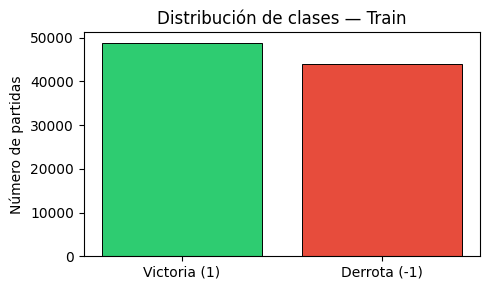

In [ ]:
# Distribución de la variable objetivo
win_counts = df_train['win'].value_counts().sort_index()
wins_train   = (df_train['win'] ==  1).sum()
losses_train = (df_train['win'] == -1).sum()
total_train  = len(df_train)

print(f'Train — Victoria  (1) : {wins_train:>6,}  ({wins_train/total_train*100:.1f}%)')
print(f'Train — Derrota  (-1) : {losses_train:>6,}  ({losses_train/total_train*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Victoria (1)', 'Derrota (-1)'], [wins_train, losses_train],
       color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.7)
ax.set_title('Distribución de clases — Train')
ax.set_ylabel('Número de partidas')
plt.tight_layout()
plt.show()

### Separar variable X e y
El objetivo es construir un modelo de **regresión logística implementado desde cero** que sea capaz de **predecir si el equipo 1 gana o pierde** una partida de Dota 2, basándose únicamente en la composición de héroes elegidos por ambos equipos.

In [ ]:
# Eliminar las columnas win y cluster_id
DROP_COLS = ['win', 'cluster_id']

# Train
y_train_raw = df_train['win'].values
X_train_df  = df_train.drop(columns=DROP_COLS)

# Test
y_test_raw  = df_test['win'].values
X_test_df   = df_test.drop(columns=DROP_COLS)

print('Columnas de características:', X_train_df.shape[1])

Columnas de características: 115


In [ ]:
#  Convertir y a (0, 1)
# Se convierte: 1 -> 1 (victoria equipo 1),  -1 -> 0 (derrota equipo 1)
y_train = ((y_train_raw + 1) / 2).astype(int)
y_test  = ((y_test_raw  + 1) / 2).astype(int)
print('Etiquetas únicas tras conversión:', np.unique(y_train))

#Convertir a arrays NumPy
X_train = X_train_df.values.astype(float)   # (92650, n_features)
X_test  = X_test_df.values.astype(float)    # (10293, n_features)

print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')

Etiquetas únicas tras conversión: [0 1]
X_train : (92650, 115)
y_train : (92650,)
X_test  : (10294, 115)
y_test  : (10294,)


## Normalización de valores
las columnas `game_mode` y `game_type` son variables categóricas codificadas numéricamente con valores más grandes. Para que el **descenso por gradiente converja estable y eficientemente**, aplicamos **estandarización (Z-score)** a esas columnas continuas, dejando intactas las columnas de héroe (ya acotadas).

In [ ]:
def featureNormalize(X, cols):
    X_norm = X.copy()

    mu    = np.mean(X[:, cols], axis=0)
    sigma = np.std(X[:, cols], axis=0)

    sigma_safe = np.where(sigma == 0, 1, sigma)

    X_norm[:, cols] = (X[:, cols] - mu) / sigma_safe

    return X_norm, mu, sigma

In [ ]:
feature_cols  = list(X_train_df.columns)
cols_to_norm  = [feature_cols.index('game_mode'),
                 feature_cols.index('game_type')]

X_train_norm, mu, sigma = featureNormalize(X_train, cols_to_norm)

# Aplicar parámetros de train al test (evitar data leakage)
sigma_safe  = np.where(sigma == 0, 1, sigma)
X_test_norm = X_test.copy()
X_test_norm[:, cols_to_norm] = (X_test[:, cols_to_norm] - mu) / sigma_safe

## Implementación de la regresión logística
#### Función sigmoidea

In [ ]:
def sigmoid(z):
    z = np.array(z)
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))

    return g

#### Función de Costo

In [ ]:
def calcularCosto(theta, X, y):
    m = y.size

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

#### Descenso por el gradiente

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

#### Agregar término de intercepción

In [ ]:
def agregar_intercepcion(X):
    m   = X.shape[0]
    ones = np.ones((m, 1))
    return np.hstack([ones, X])

X_train_b = agregar_intercepcion(X_train_norm)   # (92650, n+1)
X_test_b  = agregar_intercepcion(X_test_norm)    # (10293, n+1)

print(f'X_train con bias: {X_train_b.shape}')
print(f'X_test  con bias: {X_test_b.shape}')

X_train con bias: (92650, 116)
X_test  con bias: (10294, 116)


### Determinar valores de Theta

In [ ]:
ALPHA      = 0.1
NUM_ITERS  = 5000

n_features = X_train_b.shape[1]
theta = np.zeros(n_features).reshape(-1)
print(f'Número de parámetros θ (incluyendo bias): {n_features}')
print(f'Tasa de aprendizaje  α : {ALPHA}')
print(f'Iteraciones            : {NUM_ITERS}')

theta, J_history = descensoGradiente(theta, X_train_b, y_train, ALPHA, NUM_ITERS)

print(f'\nCosto inicial  : {J_history[0]:.6f}')
print(f'Costo final    : {J_history[-1]:.6f}')

Número de parámetros θ (incluyendo bias): 116
Tasa de aprendizaje  α : 0.1
Iteraciones            : 5000

Costo inicial  : 0.692913
Costo final    : 0.661645


theta calculado por el descenso por el gradiente: [ 1.17501879e-01  7.83298614e-04 -5.49575286e-03 -7.55999043e-02
  1.69085308e-01 -1.71476504e-01  7.96240224e-02  2.54912179e-01
  1.91974604e-01  6.62217042e-02  7.36243634e-02  2.31784212e-01
  3.65416233e-02 -1.29861602e-01 -1.31485488e-01 -2.11489663e-01
  1.09554623e-01 -1.06838287e-01  4.62001421e-02 -7.28335599e-02
  2.30017545e-01 -1.69133792e-01  1.43718988e-01 -2.37058686e-01
  2.23646694e-01  1.33251295e-02  0.00000000e+00 -2.25791386e-01
 -2.16223943e-02  1.86269734e-01  1.13806367e-01  1.53199821e-01
  6.66572694e-02  1.95767322e-01  2.44422579e-01  1.43208312e-01
 -1.42478998e-01  5.48255987e-02  3.08062017e-01  2.27363295e-01
 -2.42613056e-02 -3.27677005e-01  1.41087432e-01  6.95819210e-02
  2.77616761e-01 -1.16742398e-01  1.02978720e-01 -6.89101769e-02
 -2.24214617e-01 -1.62570009e-02  2.29353556e-01  2.25157813e-02
  1.00886256e-01  3.82289218e-02 -2.18873632e-01 -3.14868647e-01
  3.74799901e-02  2.18006866e-02 -1.3250

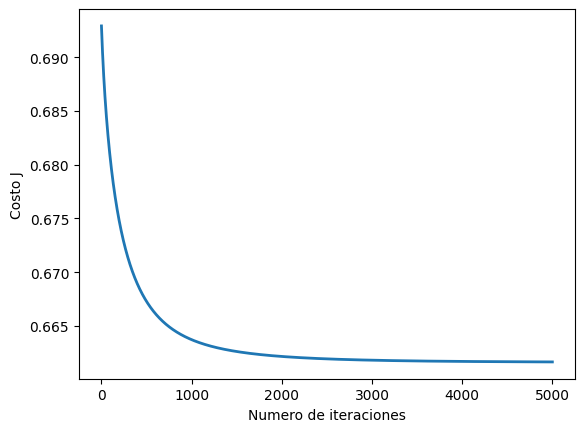

In [ ]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

## Etapa de prueba

In [ ]:
# Realizar las predicciones con el dataset de prueba
def predict_proba(X, theta):
    return sigmoid(X @ theta)


def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

y_prob_test = predict_proba(X_test_b, theta)
y_pred_test = predict(X_test_b, theta)

print(f'Ejemplos en test       : {len(y_test):,}')
print(f'Pred. Victoria (1)     : {y_pred_test.sum():,}')
print(f'Pred. Derrota  (0)     : {(1 - y_pred_test).sum():,}')

Ejemplos en test       : 10,294
Pred. Victoria (1)     : 6,006
Pred. Derrota  (0)     : 4,288


### Cálculo de la precisión

In [ ]:
def exactitud(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    return tp / (tp + fp + 1e-12)

acc  = exactitud(y_test, y_pred_test)
prec = precision(y_test, y_pred_test)

print('═' * 40)
print(f'  Exactitud  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precisión  : {prec:.4f}')
print('═' * 40)

════════════════════════════════════════
  Exactitud  : 0.5974  (59.74%)
  Precisión  : 0.6131
════════════════════════════════════════


In [ ]:
# Comparativa train vs test
y_pred_train = predict(X_train_b, theta)
acc_train    = exactitud(y_train, y_pred_train)

print('────────────────────────────────────')
print('Exactitud Train vs Test')
print(f'Train : {acc_train:.4f} ({acc_train*100:.2f}%)')
print(f'Test  : {acc:.4f} ({acc*100:.2f}%)')
print('────────────────────────────────────')

────────────────────────────────────
Exactitud Train vs Test
Train : 0.6005 (60.05%)
Test  : 0.5974 (59.74%)
────────────────────────────────────
